# Policy retrieval, measured

ArchCompass reviews a repository by showing a language model one *candidate* — a structural
shape a detector found, such as an interface with exactly one implementation — together with
the architectural policies that bear on it, and asking it to judge the one against the other.

It cannot show all 54 policies every time. That is a large prompt for every candidate in
every review, and most of the corpus is irrelevant to any particular one. So a **retriever**
picks about twenty. Everything the review then concludes is bounded by that pick: a policy
the retriever left out cannot be weighed, argued with or cited, however good the model is.

This notebook measures how good the pick is.

### How the retriever works

1. **Embedding.** An embedding model reads a piece of text and returns 768 numbers — a point
   in a 768-dimensional space. It is trained so that texts which *mean* similar things land
   near each other even when they share no words. "the ingestion queue has no size limit" and
   "bound every queue and answer overload with backpressure" have almost nothing in common
   lexically, and sit close together in this space.
2. **Indexing.** Every policy is split at its `## ` headings and each piece is embedded once,
   up front. 54 policies become 486 points, stored in SQLite.
3. **Searching.** A candidate is turned into a query string, embedded the same way, and the
   corpus is sorted by how close each point is to it — cosine similarity, which compares the
   *direction* of two vectors and ignores their length. The top twenty policies go into the
   prompt.

The embedding model is **`embeddinggemma`**, a 300M-parameter model from Google running
locally on Ollama. Nothing here calls a hosted service or a reasoning model.

**To run it:** `ollama pull embeddinggemma`, then `make evaluation`. Two minutes from cold.

How the test set is built, and how to add to it, is in [`evaluation/README.md`](README.md).

## The short version

The headline number is **recall@20**: *of the policies that should have been retrieved for a
case, what share actually landed in the top twenty?* 0.949 means about nineteen in twenty.

| | |
|---|---|
| Recall@20 | **0.949** — against 0.897 for a keyword search and 0.353 for picking at random |
| Strongest on | duplicated-knowledge and scattered-concept candidates, both **1.00** |
| Weakest on | intent cases, **0.925** |
| Release gate | **passes**, and the smallest K that passes is **16**, not the shipped 20 |
| What is left | seven misses across six cases, five of them at ranks 22–28 |
| Cost | ~128 ms a query, of which under 1% is the search — it is all the embedding call |

Two things changed since the previous run, and this notebook is why both were made.

**A sentence in a policy.** `design-for-replaceability` used to be nine of the fourteen
misses, at a median rank of **44 of 54** — near the bottom of the corpus, for exactly the
situation it was written to answer. Its `## Signals` section never described an abstraction
with one implementation, which is the whole of what a `sole_implementation` query says. One
sentence was added. That policy now misses once, at rank 22, and the pattern went from 0.735
to 0.971.

**EmbeddingGemma's task prompts.** `build_embeddings` now sends them on the Ollama path, which
the Google path had all along as a `task_type` on the request. Section 5 still prices them:
MRR 0.730 → 0.775, R@1 0.434 → 0.463.

The gate's verdict moved with them. It failed at every K before, capping at 0.839 macro recall
against a floor of 0.95. It now passes at 16 and at 20.

---

In [1]:
# The repository root, found rather than assumed: Jupyter's working directory depends on
# where it was launched from. This cell runs alone because nothing under `evaluation` is
# importable until it has.
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(ROOT)

/Users/furkan/Documents/arch_compass


In [2]:
import json
import sqlite3
import time

import httpx
import pandas as pd
import yaml

from archcompass.policies.adapters import SQLitePolicyIndex
from archcompass.policies.evaluation import choose_smallest_passing_k, evaluate_retrieval
from evaluation.harness import (
    Bm25PolicyIndex,
    InMemoryDenseIndex,
    RandomPolicyIndex,
    candidate_cases,
    chunk_report,
    evaluation_corpus,
    gate_examples,
    heading_chunks,
    label_coverage,
    load_cases,
    ollama_embeddings,
    ollama_identity,
    report,
    run_retriever,
    scoped_policies,
    shipped_corpus,
    whole_document_chunks,
)

MODEL, DIMENSIONS, OLLAMA = "embeddinggemma", 768, "http://localhost:11434"

#: The product's name for these vectors, asked for rather than assembled — it carries the
#: `:task-prompted` suffix, and an index built under the wrong name is one a review cannot
#: read.
IDENTITY = ollama_identity(model=MODEL, dimensions=DIMENSIONS)

#: 20 is the shipped `DENSE_RETRIEVER_RELEASE_TOP_K`. The smaller values are where a
#: retriever that is merely *eventually* right stops looking right.
KS = (1, 3, 5, 8, 10, 12, 16, 20)

RESULTS = ROOT / "evaluation" / "results"
RESULTS.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 72)

# Fail here, with a sentence, rather than three cells later inside a retry loop.
try:
    installed = {
        item["name"].split(":")[0]
        for item in httpx.get(f"{OLLAMA}/api/tags", timeout=5).json()["models"]
    }
except httpx.HTTPError as error:
    raise SystemExit(f"Ollama is not answering on {OLLAMA}: {error}") from error
if MODEL not in installed:
    raise SystemExit(f"`ollama pull {MODEL}` first; this host has {sorted(installed)}")

print(f"{IDENTITY}  |  ollama holds {', '.join(sorted(installed))}")

ollama:embeddinggemma:768:task-prompted  |  ollama holds embeddinggemma, gemma4


## 1. What is being measured

**The corpus** is the 54 policies ArchCompass ships, read by the same parser the product uses
— so a policy that has drifted out of the required format fails this cell rather than quietly
producing a worse embedding.

**Why chunks rather than whole documents.** A policy is a long document covering intent,
signals, consequences, exceptions and two worked examples. Embedded whole, all of that
averages into one point, and the two sentences that actually answer a query get diluted by
the eight paragraphs that do not. Splitting at the `## ` headings gives each section its own
point, and a policy then scores as its best-matching section. Section 5 measures whether that
is worth nine times the storage.

**The test set** is 68 cases. Each is a query plus the policies that are the right answer to
it, and there are two kinds:

- **28 candidate cases**, which are not written by hand. The example repositories under
  `examples/cases` are parsed by the production analyser, run through the production
  detectors, and turned into a query by the production `retrieval_query`. These are the exact
  strings a real review produces.
- **40 intent cases**, which are design situations described the way an engineer would
  describe one — *"the ingestion queue has no size limit; under load the process holds a
  million messages in memory"*. They exist because the detectors only know three shapes, so a
  test set built from those alone would measure the corpus for three questions and say
  nothing about the other fifty policies. Each is deliberately written in the vocabulary of
  the **problem**, not of the policy that answers it, because a query that quotes its own
  answer tests word overlap rather than meaning.

**The labels are graded**, because relevance here is not a yes or no:

| grade | meaning | read by |
|---|---|---|
| `bearing` | a reviewer would cite this in the verdict — missing it is a wrong retrieval | recall, MRR, MAP |
| `supporting` | clearly relevant, but the verdict does not turn on it | nDCG only |
| `adjacent` | defensible to include, wrong to call a miss | nDCG only |

Most cases have two bearing policies. Grading this way means a sensible extra result does not
count against the retriever, while nDCG can still tell a run that put the right answer first
from one that buried it at rank eighteen.

In [3]:
corpus = shipped_corpus(ROOT)
full_corpus = evaluation_corpus(ROOT)      # + four scoped policies, used by section 6
scope_fixture = scoped_policies(ROOT)
cases = load_cases(ROOT)

named, unlabelled, unknown = label_coverage(cases, full_corpus)
if unknown:
    raise SystemExit(f"Labels name policies that do not exist: {sorted(unknown)}")

chunks = chunk_report(corpus, heading_chunks)
candidate_count = sum(case.kind == "candidate" for case in cases)
bearings = sum(len(case.bearing) for case in cases) / len(cases)
labelled = len(named & {policy.id for policy in corpus})

pd.DataFrame(
    [
        ("policies", chunks.policies),
        ("chunks in the index", f"{chunks.chunks}  ({chunks.chunks_per_policy:.0f} per policy)"),
        ("longest chunk", f"~{chunks.longest_estimated_tokens} tokens (model context is 2048)"),
        ("cases", f"{len(cases)}  ({candidate_count} candidate, "
                  f"{len(cases) - candidate_count} intent)"),
        ("bearing policies per case", f"{bearings:.2f}"),
        ("shipped policies a label names", f"{labelled} of {len(corpus)}"),
    ],
    columns=["", "value"],
).set_index("")

,value
,
policies,54
chunks in the index,486 (9 per policy)
longest chunk,~447 tokens (model context is 2048)
cases,"68 (28 candidate, 40 intent)"
bearing policies per case,1.62
shipped policies a label names,54 of 54


In [4]:
# One candidate query, verbatim — this is the whole text the retriever is given.
print(cases[0].query)
print()
print("bearing:   ", sorted(cases[0].bearing))
print("supporting:", sorted(cases[0].labels.supporting))

Pattern: sole_implementation
Candidate: payments.gateway.PaymentGateway is implemented only by payments.stripe_gateway.StripeGateway.
Participants: payments.gateway.PaymentGateway, payments.stripe_gateway.StripeGateway
Measurements: implementations: 1 implementations; dependants_of_abstraction: 0 references
Detection limits: Counted from statically resolvable inheritance and structural conformance in this snapshot. Implementations registered dynamically, supplied by another repository, or planned but unwritten are not visible, and an abstraction may be deliberate at a port boundary where only one adapter exists today.
Constraints: Card handling stays with the payment provider; we do not want PCI scope.; Billing and reporting are owned by different teams on the same release train.

bearing:    ['contain-dependencies', 'delay-premature-abstraction']
supporting: ['design-for-replaceability', 'hide-implementation-details', 'model-stable-concepts']


## 2. Building the index

Embedding 486 chunks takes about eight seconds, and only has to happen when the corpus
changes — so the shipped index keeps the vectors in SQLite and reuses them.

Two indexes get built here. `SQLitePolicyIndex` is the product's. `InMemoryDenseIndex` is
this harness's, and exists for one reason: section 5 varies how the corpus is chunked, which
the shipped index treats as fixed, and it caches embeddings across variants so a sweep does
not re-embed the same text four times.

A number out of the harness's index is only worth reading if it agrees with the product's, so
the two are checked against each other on all 68 queries before anything is measured.

In [5]:
embeddings = ollama_embeddings(model=MODEL, dimensions=DIMENSIONS, base_url=OLLAMA)

production = SQLitePolicyIndex(
    lambda: sqlite3.connect(RESULTS / "policy-index.sqlite3"),
    embeddings,
    embedding_identity=IDENTITY,
    dimensions=DIMENSIONS,
)
memory = InMemoryDenseIndex(embeddings, embedding_identity=IDENTITY, dimensions=DIMENSIONS)

started = time.perf_counter()
production.synchronize(corpus)
sqlite_build = time.perf_counter() - started

started = time.perf_counter()
memory.synchronize(corpus)          # never cached between runs, so always a real embed
corpus_embed = time.perf_counter() - started

differ = [
    case.id
    for case in cases
    if tuple(m.policy_id for m in production.search(case.query, limit=20))
    != tuple(m.policy_id for m in memory.search(case.query, limit=20))
]
if differ:
    raise SystemExit(f"{len(differ)} rankings differ between the two indexes: {differ[:3]}")

print(f"sqlite index   {sqlite_build:5.1f}s   (0s when the workspace already holds it)")
print(f"memory index   {corpus_embed:5.1f}s   embeds all {chunks.chunks} chunks every time")
print(f"parity         identical top-20 rankings on all {len(cases)} queries")

sqlite index     9.1s   (0s when the workspace already holds it)
memory index     7.9s   embeds all 486 chunks every time
parity         identical top-20 rankings on all 68 queries


## 3. How good is the ranking?

Four numbers, and what each is for.

**recall@k** — of the bearing policies for a case, the share inside the first *k* results.
This is the one that matters, because a policy outside the window never reaches the prompt at
all. Read `R@20 = 0.897` as "about nine in ten of the right answers made it in".

**MRR**, mean reciprocal rank — `1 / rank` of the *first* bearing hit, averaged over cases. It
answers "how far down do I read before hitting something right?". Always first scores 1.0;
always second, 0.5; always fourth, 0.25. A score of 0.730 sits between first and second.

**MAP**, mean average precision — like MRR, but it keeps going instead of stopping at the
first hit, so it rewards getting *all* the bearing policies early. Two right answers at ranks
1 and 2 beat the same two at ranks 1 and 15, which recall@20 cannot distinguish.

**nDCG@10** — the only metric that reads the `supporting` and `adjacent` grades. Each result
contributes its grade as "gain", divided by a penalty that grows with how far down it sits;
the total is then divided by the score of the best arrangement those grades allow, so 1.0
means a perfect ranking. It is what notices a retriever that finds the right answer but
buries it.

`precision@k` is deliberately absent. With about two bearing policies per case it cannot
exceed `2/k`, so a *perfect* retriever scores 0.1 at k=20 — it measures the size of the
window, not the quality of the ranking.

All four are **macro averages**: every case counts once regardless of how many bearing
policies it has, so the six near-identical `boundary-review` ports cannot outvote a case that
appears once.

In [6]:
shipped = report.evaluate(memory, corpus, cases, label=f"{MODEL} (shipped)", ks=KS)

display(report.table(shipped))
print("recall@20 by kind:   ", {k: round(v, 3) for k, v in shipped.summary.recall_by_kind})
print("recall@20 by pattern:", {k: round(v, 3) for k, v in shipped.summary.recall_by_pattern})

,cases,R@1,R@3,R@5,R@8,R@10,R@12,R@16,R@20,MRR,MAP,nDCG@10,complete@20
variant,,,,,,,,,,,,,
embeddinggemma (shipped),68,0.463,0.654,0.757,0.816,0.86,0.875,0.926,0.949,0.775,0.641,0.666,0.912


recall@20 by kind:    {'candidate': 0.982, 'intent': 0.925}
recall@20 by pattern: {'duplicated_knowledge': 1.0, 'intent': 0.925, 'scattered_concept': 1.0, 'sole_implementation': 0.971}


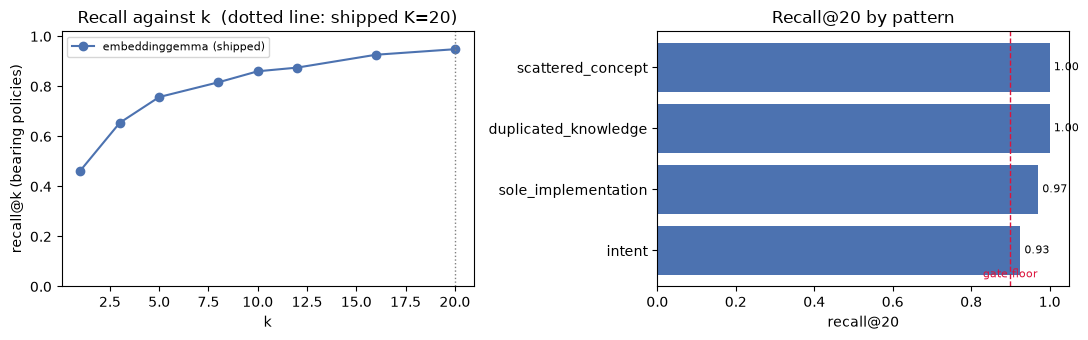

In [7]:
report.recall_charts(shipped, ks=KS)

Two things stand out.

Recall is still climbing at the shipped window — 0.926 at k=16, 0.949 at k=20 — so unlike the
previous run there is no point above which a wider window buys nothing. The gate in section 6
still prefers 16, because what it asks of a retriever is already met there; recall alone would
keep paying for a few more places.

And the loss is no longer concentrated in one candidate pattern. `duplicated_knowledge` and
`scattered_concept` are perfect at 1.00 and `sole_implementation` reaches 0.971. The weakest
column is now the intent cases at 0.925 — the half of the set written in the problem's
vocabulary rather than a detector's. Section 4 looks at what is left.

## 4. Where it misses

An aggregate says how much was missed, never what — and *what* is the only part anyone can
act on.

One distinction decides the whole response. If a right answer landed at **rank 22**, the
retriever understood the query and the window was two places too narrow; widening K fixes it.
If it landed at **rank 45 of 54**, the retriever never connected that query to that document,
and no window affordable inside a prompt would have reached it. The first is a parameter, the
second is a corpus problem.

Telling them apart needs the full ranking rather than the top twenty, so this section ranks
all 54 policies and reports where each missed policy actually came out.

In [8]:
misses = report.miss_table(shipped, cases)
print(f"{misses.index.nunique()} of {len(cases)} cases miss a bearing policy inside K=20")
display(misses)

6 of 68 cases miss a bearing policy inside K=20


,pattern,missed policy,true rank
case,,,
"warehouse-sync/sole_implementation/SqliteStockLedger,StockLedger",sole_implementation,design-for-replaceability,22
intent/service-layer-forwards-everything,intent,prefer-deep-modules,26
intent/every-caller-repeats-the-same-six-lines,intent,pull-complexity-downward,26
intent/interface-shaped-by-its-first-caller,intent,model-stable-concepts,26
intent/every-caller-repeats-the-same-six-lines,intent,prefer-deep-modules,28
intent/mutable-settings-dict,intent,give-state-one-writer,35
intent/interface-named-after-the-broker,intent,name-for-meaning,36


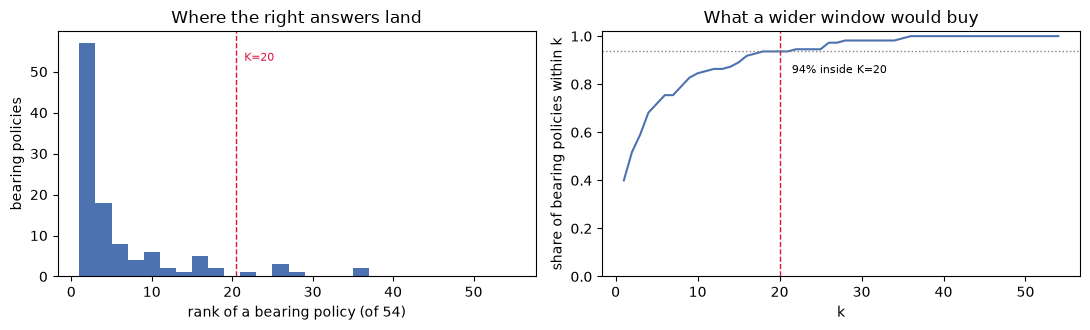

5 of 7 misses sit inside rank 30 — a wider window would find them.
2 sit below it, which no K reachable inside a prompt budget reaches.



,misses,median_rank
missed policy,,
prefer-deep-modules,2,27.0
design-for-replaceability,1,22.0
give-state-one-writer,1,35.0
model-stable-concepts,1,26.0
name-for-meaning,1,36.0
pull-complexity-downward,1,26.0


In [9]:
report.rank_charts(shipped, cases, corpus_size=len(corpus))

near = int((misses["true rank"] <= 30).sum())
print(f"{near} of {len(misses)} misses sit inside rank 30 — a wider window would find them.")
print(f"{len(misses) - near} sit below it, which no K reachable inside a prompt budget reaches.")
print()
display(
    misses.groupby("missed policy")
    .agg(misses=("pattern", "count"), median_rank=("true rank", "median"))
    .sort_values("misses", ascending=False)
)

**The concentration is gone.** In the previous run one policy was nine of the fourteen misses:
`design-for-replaceability`, at a median rank of **44 out of 54**, on exactly the
sole-implementation candidates it was written for. That was a corpus problem rather than a
tuning one, and it was visible in the document — the policy's `## Signals` section, the chunk
such a query has to match, never described an abstraction with exactly one implementation.

A sentence was added to that section describing the shape: an interface with one
implementation, nothing depending on the abstraction, a seam that has never been asked to
hold. The policy now misses once, at **rank 22**, and `sole_implementation` went from 0.735 to
0.971. BM25 improved alongside it — 0.853 to 0.897 at k=20 — which is the check worth having:
the sentence added something a reader would also have wanted, not something only an embedding
could see.

What is left is a different kind of miss. Five of the seven sit between ranks 22 and 28, just
outside a twenty-place window — the retriever understood those queries and ran out of room.
The other two sit at 35 and 36. No policy accounts for more than two of them, so there is no
document to fix here in the way there was one before; the next move on this list is a window,
and section 6 is where a window is decided.

## 5. Compared to what, and does the design pay?

A recall figure on its own is unreadable. 0.949 is excellent against a floor of 0.35 and
less striking against a plain keyword search that reaches 0.90 for free. So two reference
points, both run through the same interface as the real thing:

- **BM25** is the standard keyword ranking function — in short, it scores a document by how
  many of the query's words appear in it, weighting rare words more heavily and correcting
  for document length. It has no notion of meaning whatsoever. Left untuned on purpose: a
  baseline adjusted until it loses has stopped being a baseline.
- **Random** is a deterministic shuffle, seeded per query so a re-run reproduces it. With 54
  policies and about two right answers per case, drawing 20 finds roughly a third of them by
  luck — the floor any method has to clear before it has done anything at all.

Both index the same chunks and use the same "a policy scores as its best chunk" reduction, so
nothing but the ranking function differs between the three rows below.

,cases,R@1,R@3,R@5,R@8,R@10,R@12,R@16,R@20,MRR,MAP,nDCG@10,complete@20
variant,,,,,,,,,,,,,
embeddinggemma (shipped),68,0.463,0.654,0.757,0.816,0.860,0.875,0.926,0.949,0.775,0.641,0.666,0.912
BM25 (lexical),68,0.368,0.522,0.640,0.772,0.824,0.853,0.868,0.897,0.614,0.536,0.578,0.809
random (floor),68,0.000,0.044,0.103,0.191,0.221,0.250,0.287,0.353,0.101,0.085,0.140,0.206


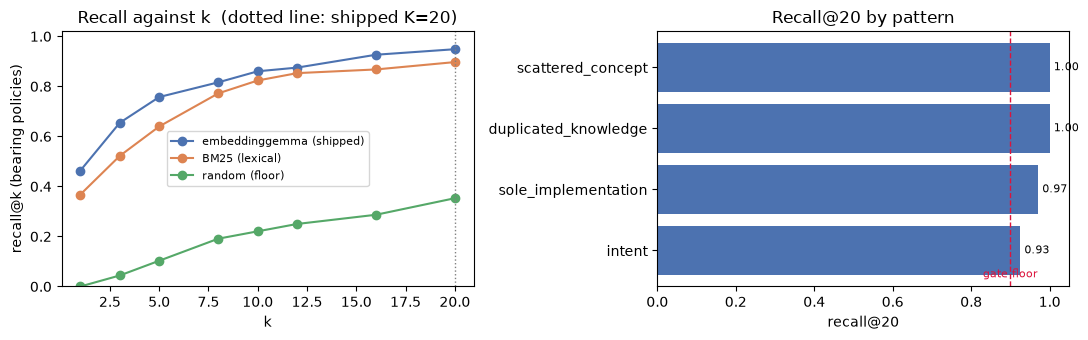

In [10]:
lexical = report.evaluate(Bm25PolicyIndex(), corpus, cases, label="BM25 (lexical)", ks=KS)
floor = report.evaluate(RandomPolicyIndex(), corpus, cases, label="random (floor)", ks=KS)

display(report.table(shipped, lexical, floor))
report.recall_charts(shipped, lexical, floor, ks=KS)

The embeddings beat keyword search everywhere, and the gap is widest at the top of the
ranking — R@1 0.463 against 0.368, MRR 0.775 against 0.614 — which is precisely the part a
prompt budget spends.

They are also not winning on word overlap, which is the thing BM25 *is*: it trails by 0.052 at
recall@20 and by 0.161 on MRR. The intent cases are deliberately written in the problem's
vocabulary rather than the policy's and still reach 0.925. The candidate half scores higher
now, 0.982, but that is the sentence added in section 4 rather than anything about vocabulary —
those are the queries it was added for.

Now the two design choices the shipped index makes. Each is tested by changing that one thing
and holding everything else fixed.

**Task prompts.** EmbeddingGemma was trained with a prefix on every input saying what the text
is *for* — `task: search result | query: …` when embedding a search, `title: … | text: …` when
embedding a document to be found. The prefixes are how the model knows to place a short
question and the long answer to it in the same neighbourhood, instead of treating them as two
unlike texts. Google's API carries the same instruction as a `task_type` field and
`build_embeddings` has always sent it there. Ollama's API takes only text, so until this run
the local path sent neither prefix; it now sends both, and the row below is what taking them
away again costs.

**Chunking.** Nine vectors per policy instead of one, costing nine times the storage and nine
times the embedding calls when the index is built. The question is whether matching a
*section* beats matching a whole document.

In [11]:
bare = InMemoryDenseIndex(
    ollama_embeddings(model=MODEL, dimensions=DIMENSIONS, base_url=OLLAMA, task_prompts=False),
    embedding_identity=f"{IDENTITY}:unprompted",
    dimensions=DIMENSIONS,
)
whole = InMemoryDenseIndex(
    embeddings,
    embedding_identity=f"{IDENTITY}:whole",
    dimensions=DIMENSIONS,
    chunker=whole_document_chunks,
)

display(
    report.table(
        shipped,
        report.evaluate(bare, corpus, cases, label="no task prompts", ks=KS),
        report.evaluate(whole, corpus, cases, label="whole documents", ks=KS),
        ks=(1, 5, 10, 20),
    )
)

,cases,R@1,R@5,R@10,R@20,MRR,MAP,nDCG@10,complete@20
variant,,,,,,,,,
embeddinggemma (shipped),68,0.463,0.757,0.860,0.949,0.775,0.641,0.666,0.912
no task prompts,68,0.434,0.750,0.882,0.949,0.730,0.625,0.658,0.897
whole documents,68,0.471,0.743,0.860,0.912,0.759,0.644,0.682,0.853


In [12]:
# The third choice: `retrieval_query` appends the case's constraints to every query. Only the
# 28 candidate cases have a case to strip, so this is scored on its own rather than mixed in.
with_case = candidate_cases(ROOT, with_constraints=True)
without_case = candidate_cases(ROOT, with_constraints=False)

display(
    report.table(
        report.evaluate(memory, corpus, with_case, label="with case constraints", ks=KS),
        report.evaluate(memory, corpus, without_case, label="without them", ks=KS),
        ks=(1, 5, 10, 20),
    )
)

,cases,R@1,R@5,R@10,R@20,MRR,MAP,nDCG@10,complete@20
variant,,,,,,,,,
with case constraints,28,0.286,0.679,0.875,0.982,0.759,0.536,0.653,0.964
without them,28,0.321,0.714,0.857,0.982,0.774,0.562,0.651,0.964


- **Task prompts buy the top of the ranking and nothing below it.** R@1 0.434 → 0.463 and MRR
  0.730 → 0.775, for two string formats. Recall@20 is identical at 0.949, and at k=10 the
  unprompted index is actually *ahead*, 0.882 to 0.860. So the prompts do not find policies
  that were unreachable; they move a case's first right answer up, which is the part of a
  ranking a prompt budget spends.
- **Heading chunks beat whole documents on coverage, not on precision.** Whole documents are
  now slightly ahead at rank 1 — 0.471 against 0.463 — and on nDCG@10, 0.682 against 0.666.
  What nine times the vectors buys is the tail: recall@20 0.949 against 0.912, complete
  coverage 0.912 against 0.853. Worth keeping, and for the opposite reason the previous run
  gave, which is a caution about how firmly to hold either reading.
- **The case constraints still cost precision.** `retrieval_query` appends the case's
  constraints to every query — the one part of it a *user* writes. Doing so drops R@1 from
  0.321 to 0.286 and MRR from 0.774 to 0.759, while recall@20 does not move at all. The gap
  narrowed since the previous run; the direction did not. Still 28 cases, still a thin basis
  for removing a user-facing input — it wants a second test set before anyone acts on it.

## 6. Does it pass the release gate?

`docs/policy-retrieval.md` sets conditions a retriever has to meet before its K and version
constants may move. It is a pass/fail check meant to run before a release, not a score.

This section runs the **whole shipped retriever**, not just the ranking, at each of the four K
values the gate evaluates. That distinction matters, because ranking is only half of what the
retriever does. The other half is a merge rule: a policy scoped to your organisation or your
repository, or marked *required*, goes into the prompt whatever the embeddings think of it.
The second cell checks that arm on its own.

The corpus grows by four policies here. Every one of the shipped 54 is general guidance, so
without them the merge rule would have nothing to include and the check would pass vacuously.

In [13]:
gate_index = InMemoryDenseIndex(
    embeddings, embedding_identity=f"{IDENTITY}:gate", dimensions=DIMENSIONS
)
gate_index.synchronize(full_corpus)

runs = {k: run_retriever(gate_index, full_corpus, with_case, top_k=k) for k in (8, 12, 16, 20)}
examples = {k: gate_examples(run, full_corpus) for k, run in runs.items()}

display(report.gate_table({k: evaluate_retrieval(v) for k, v in examples.items()}))

try:
    chosen, result = choose_smallest_passing_k(lambda k: examples[k])
    print(f"PASS — smallest passing K is {chosen} (macro recall {result.macro_recall:.3f})")
except ValueError as refusal:
    print(f"FAIL — {refusal}")

,macro recall,worst pattern,complete coverage,mandatory coverage,passes
K,,,,,
8,0.768,0.735,0.536,1.0,False
12,0.893,0.824,0.786,1.0,False
16,0.964,0.941,0.929,1.0,True
20,0.982,0.971,0.964,1.0,True
floor,0.950,0.900,0.750,1.0,True


PASS — smallest passing K is 16 (macro recall 0.964)


In [14]:
# The mandatory arm on its own: every scoped or required policy that applies must be selected
# whatever the ranking says, and one that does not apply must never appear.
checks = [
    {
        "repository": case.repository,
        "policy": policy.id,
        "must be selected": (
            applies
            and (policy.scope.value != "general" or policy.strength.value == "required")
        ),
        "selected": policy.id in {item.id for item in retrieved.policies},
    }
    for case, retrieved in runs[20]
    for policy in scope_fixture
    for applies in [
        policy.applies_in(
            user=case.case.policy_context.user,
            organisation=case.case.policy_context.organisation,
            repository=case.case.policy_context.repository,
        )
    ]
]
scope_frame = pd.DataFrame(checks).assign(ok=lambda f: f["must be selected"] == f["selected"])

print(f"{int(scope_frame['ok'].sum())}/{len(scope_frame)} checks correct across "
      f"{scope_frame['repository'].nunique()} cases")
display(
    scope_frame.pivot_table(
        index="policy", columns="repository", values="selected", aggfunc="all"
    )
)
if not scope_frame["ok"].all():
    display(scope_frame[~scope_frame["ok"]])

112/112 checks correct across 5 cases


repository,acme-shop,audiobook-studio,boundary-review,speech-vendor,warehouse-sync
policy,,,,,
general-record-the-verdict,True,True,True,True,True
org-nightly-batch-window,False,False,False,False,False
org-vendor-adapter-boundary,True,True,False,True,False
repo-ledger-single-writer,False,False,False,False,True


It passes, at K=16 and at K=20, so `choose_smallest_passing_k` selects **16**. The previous run
failed at every K and capped at 0.839 macro recall against a floor of 0.95, so what moved here
is not a threshold: it is the corpus and the embedding path, both changed on this notebook's
evidence and both re-measured by it.

The shipped constant is still `DENSE_RETRIEVER_RELEASE_TOP_K = 20`, which this gate now says is
four places wider than it needs to be. Moving it is a release decision taken by running
`archcompass retrieval evaluate --from evaluation/results/evaluation.yaml`, not by a cell here.
What this section establishes is that the smaller K is available, and section 4 is the reason
to think twice about the smaller one still: five of the seven remaining misses sit at ranks
22–28, and a narrower window does not move them closer.

The mandatory merge, meanwhile, is right in all 112 checks — every applicable scoped or
required policy selected, the one scoped to a different organisation never selected. That half
of the retriever needs no work.

**One gate condition is missing from the table.** `verdict_regression` asks whether the verdict
a model reaches on the twenty retrieved policies matches the verdict it reaches on all 54 — in
other words, whether shrinking the prompt changed the answer. Measuring it costs a
reasoning-model call per candidate per K, which nothing offline can pay, so the column is left
out rather than filled with a zero that would read as a pass. A K could clear everything above
and still change verdicts, and that applies to the 16 this section just selected.

## 7. What it costs

Retrieval runs once per candidate, on the request path, while somebody waits.

In [15]:
sample = [case.query for case in cases[:20]]

timings = []
for query in sample:
    started = time.perf_counter()
    production.search(query, limit=20)      # no query cache, so each pays for its own embed
    timings.append(time.perf_counter() - started)
end_to_end = pd.Series(timings)

started = time.perf_counter()
for query in sample:
    memory.search(query, limit=20)          # already embedded, so this is the scan alone
scan = (time.perf_counter() - started) / len(sample)

median = end_to_end.median()
display(
    pd.DataFrame(
        [
            ("build the index", f"{corpus_embed:.0f} s",
             f"{chunks.chunks} chunks, once per corpus edit"),
            ("one retrieval, median", f"{median * 1000:.0f} ms",
             "embed the query, then scan"),
            ("one retrieval, p95", f"{end_to_end.quantile(0.95) * 1000:.0f} ms", ""),
            ("  the scan alone", f"{scan * 1000:.1f} ms", f"{scan / median:.1%} of it"),
            ("  the embedding call", f"{(median - scan) * 1000:.0f} ms",
             "the whole cost, effectively"),
            ("a review with 8 candidates", f"{8 * median:.1f} s", "with the index warm"),
        ],
        columns=["", "time", "note"],
    ).set_index("")
)

,time,note
,,
build the index,8 s,"486 chunks, once per corpus edit"
"one retrieval, median",128 ms,"embed the query, then scan"
"one retrieval, p95",154 ms,
the scan alone,0.4 ms,0.3% of it
the embedding call,127 ms,"the whole cost, effectively"
a review with 8 candidates,1.0 s,with the index warm


Almost all of it is the call to the embedding model. The similarity search over 486 vectors is
a rounding error beside it.

That rules out a whole category of optimisation. When vector search is slow the usual answer is
an approximate nearest-neighbour index, which trades exactness for speed — here it would buy
nothing, because the exact search is already free at this corpus size. If retrieval needs to be
faster, the embedding call is the only thing worth attacking.

## 8. Results on disk

`case-scores.csv` and `variant-summary.csv` are the evidence behind every table above — one
row per case per variant, so a number in this notebook can be traced to the case that produced
it. `evaluation.yaml` is the file `archcompass retrieval evaluate --from` reads, so the gate in
section 6 can be re-checked from a shell without opening a kernel.

In [16]:
variants = [shipped, lexical, floor]

pd.DataFrame(
    [
        {"variant": item.label, "case": score.case_id, "kind": score.kind,
         "pattern": score.pattern,
         **{f"R@{k}": value for k, value in score.bearing_recall_at_k},
         "MRR": score.reciprocal_rank, "AP": score.average_precision,
         "nDCG@10": score.ndcg_at_10, "missed@20": ", ".join(score.missed_at_20)}
        for item in variants
        for score in item.scores
    ]
).to_csv(RESULTS / "case-scores.csv", index=False)

report.table(*variants).to_csv(RESULTS / "variant-summary.csv")

(RESULTS / "evaluation.yaml").write_text(
    yaml.safe_dump(
        {
            "embedding_identity": IDENTITY,
            "results": {
                k: [
                    {"pattern": e.pattern,
                     "expected_policy_ids": sorted(e.expected_policy_ids),
                     "selected_policy_ids": list(e.selected_policy_ids),
                     "required_policy_ids": sorted(e.required_policy_ids),
                     "scoped_policy_ids": sorted(e.scoped_policy_ids)}
                    for e in items
                ]
                for k, items in examples.items()
            },
        },
        sort_keys=False,
    ),
    encoding="utf-8",
)

(RESULTS / "summary.json").write_text(
    json.dumps(
        {
            "embedding_identity": IDENTITY,
            "corpus_policies": len(corpus),
            "corpus_chunks": chunks.chunks,
            "cases": len(cases),
            "recall_at_k": dict(shipped.summary.recall_at_k),
            "mrr": shipped.summary.mrr,
            "map": shipped.summary.map_score,
            "ndcg_at_10": shipped.summary.ndcg_at_10,
            "recall_by_pattern": dict(shipped.summary.recall_by_pattern),
            "gate_passes": any(evaluate_retrieval(v).passed for v in examples.values()),
            "corpus_embed_seconds": corpus_embed,
            "retrieval_seconds_median": float(median),
        },
        indent=2,
    ),
    encoding="utf-8",
)

for path in sorted(RESULTS.glob("*")):
    if path.suffix != ".sqlite3":
        print(f"{path.relative_to(ROOT)}  {path.stat().st_size:,} bytes")
print()
print("uv run archcompass retrieval evaluate --from evaluation/results/evaluation.yaml")

evaluation/results/case-scores.csv  35,393 bytes
evaluation/results/evaluation.yaml  84,245 bytes
evaluation/results/retrieval-evaluation.html  568,066 bytes
evaluation/results/summary.json  752 bytes
evaluation/results/variant-summary.csv  352 bytes

uv run archcompass retrieval evaluate --from evaluation/results/evaluation.yaml


---

## What this does not measure

- **Whether a smaller prompt changes the verdict.** The `verdict_regression` gate condition,
  which needs a reasoning model. Uncovered here, and the most important gap.
- **Disagreement about the right answer.** The bearing sets are one person's reading of what a
  reviewer would cite, and the gate now passes against them. A different labeller would draw
  some of those lines elsewhere; nothing here measures how far the verdict would move if they
  did, and a gate is easier to trust while it is failing than once it agrees with you.
- **Any other embedding model.** Nothing compares `embeddinggemma` against
  `gemini-embedding-2`, the hosted model the product defaults to. The harness would run it
  unchanged — swap `ollama_embeddings` for a Google `EmbeddingModelConfig` — but it spends API
  quota, so it stays out of the offline path.
- **Detector shapes that do not exist yet.** The candidate half of the set can only ask about
  the three patterns the detectors find. A new detector arrives here with no labels behind it.